AVALIAÇÃO DE CARROS POR MEIO DE SUAS CARACTERÍSTICAS

In [150]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import axes3d
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
carE_df = pd.read_csv("carEvaluation.csv")
carE_df.head()

,buying,maint,doors,persons,lug_boot,safety,values
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
carE_df.describe()

,buying,maint,doors,persons,lug_boot,safety,values
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [4]:
carE_df.info()
carE_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   values    1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
values      0
dtype: int64

Como pode-se perceber, nos dados do meu dataset escolhido não há dados faltosos, que poderiam influenciar nas minhas contas, sendo assim, a necessidade de uma limpeza prévia. Com o intuito de por em pratica a Atividade 1, modifiquei alguns itens da minha lista para implementar um método de limpeza (Apenas para teste, o utilizado no decorrer do trabalho é o original).

In [5]:
carE_teste_df = pd.read_csv("carEvaluation_limpeza.csv")
carE_teste_df.info()
carE_teste_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1714 non-null   str  
 1   maint     1714 non-null   str  
 2   doors     1720 non-null   str  
 3   persons   1720 non-null   str  
 4   lug_boot  1714 non-null   str  
 5   safety    1713 non-null   str  
 6   values    1721 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


buying      14
maint       14
doors        8
persons      8
lug_boot    14
safety      15
values       7
dtype: int64

Apaguei alguns valores, e usei o isnull() para identificar e o sum() para somar esse valores que eu removi, agora implementarei o método hot-deck que consiste em preencher com valor aleatorio de mesmo atributo de um objeto similar. Vou mostrar os 10 primeiros já que eu tirei alguns dados dele, e depois vou mostar por quais dados foram atribuidos.

In [6]:
carE_teste_df.head(10)

,buying,maint,doors,persons,lug_boot,safety,values
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,NaN,NaN,unacc
6,vhigh,vhigh,2,2,NaN,NaN,unacc
7,vhigh,vhigh,2,2,NaN,NaN,unacc
8,vhigh,vhigh,2,2,NaN,NaN,unacc
9,vhigh,vhigh,2,4,NaN,NaN,unacc


In [7]:
for col in carE_teste_df.columns:
    missing = carE_teste_df[col].isnull()
    carE_teste_df.loc[missing, col] = np.random.choice(carE_teste_df[col].dropna(), size=missing.sum())

In [8]:
carE_teste_df.head(10)

,buying,maint,doors,persons,lug_boot,safety,values
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,small,low,unacc
6,vhigh,vhigh,2,2,small,low,unacc
7,vhigh,vhigh,2,2,med,low,unacc
8,vhigh,vhigh,2,2,small,med,unacc
9,vhigh,vhigh,2,4,med,high,unacc


In [9]:
carE_teste_df.info()
carE_teste_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   values    1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
values      0
dtype: int64

Com o teste agora temos nenhuma variável faltando, ou seja, todos os valores preenchidos.

Implementando os exercícios da Atividade 2: já que meu dataset é composto por dados categoricos, agora passarei para numérico para realizar a padronização e depois o PCA (já voltando com a tabela original).

In [12]:
encoders = {}
carE_numerico_Hot_df = carE_df.copy()
carE_numerico_Hot_df = pd.get_dummies(carE_numerico_Hot_df)

carE_label_df = carE_df.copy()

encoders = {}

for col in carE_label_df.columns:
    le = LabelEncoder()
    carE_label_df[col] = le.fit_transform(carE_label_df[col])
    encoders[col] = le  # salva para usar depois (importante)

carE_label_df.head()
print(carE_numerico_Hot_df.head())


   buying_high  buying_low  buying_med  buying_vhigh  maint_high  maint_low  \
0        False       False       False          True       False      False   
1        False       False       False          True       False      False   
2        False       False       False          True       False      False   
3        False       False       False          True       False      False   
4        False       False       False          True       False      False   

   maint_med  maint_vhigh  doors_2  doors_3  ...  lug_boot_big  lug_boot_med  \
0      False         True     True    False  ...         False         False   
1      False         True     True    False  ...         False         False   
2      False         True     True    False  ...         False         False   
3      False         True     True    False  ...         False          True   
4      False         True     True    False  ...         False          True   

   lug_boot_small  safety_high  safety_low  

Todos os dados foram passados para uma forma numérica utilizando o LabelEncoder, basicamente como se passasse e forma de opção, já que os valores dos atributos eram separados de tal forma:
   buying       v-high, high, med, low
   maint        v-high, high, med, low
   doors        2, 3, 4, 5-more
   persons      2, 4, more
   lug_boot     small, med, big
   safety       low, med, high

   class:
   values       unacc, acc, good, vgood

Já que meus dados são categóricos não faria muito sentido a implementação de padronização, já que a variação e a distancia dos dados não indicariam números reais, mas sim representativos. Mas para o exercício realizarei a implementação por meio do z-score e depois o PCA.

In [147]:
scaler = StandardScaler()
carE_PCA_df = carE_numerico_Hot_df.drop('values_acc', axis=1)
carE_PCA_df = carE_numerico_Hot_df.drop('values_good', axis=1)
carE_PCA_df = carE_numerico_Hot_df.drop('values_unacc', axis=1)
carE_PCA_df = carE_numerico_Hot_df.drop('values_vgood', axis=1)
y = carE_df['values']

X_scaled = scaler.fit_transform(carE_PCA_df)

In [148]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.1179018 , 0.06592836, 0.06254257])

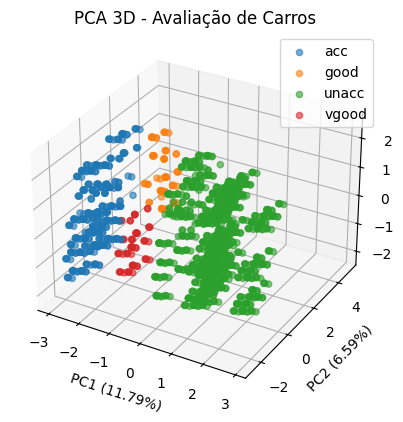

In [149]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

classes = np.unique(y)

for classe in classes:
        ax.scatter(
    X_pca[y == classe, 0],
    X_pca[y == classe, 1],
    X_pca[y == classe, 2],
    label=classe,
    alpha=0.6,
    s=20
)
    

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)')

ax.set_title('PCA 3D - Avaliação de Carros')
ax.legend()

plt.show()

In [121]:
corr = carE_PCA_df.corr()
corr

,buying_high,buying_low,buying_med,buying_vhigh,maint_high,maint_low,maint_med,maint_vhigh,doors_2,doors_3,...,persons_more,lug_boot_big,lug_boot_med,lug_boot_small,safety_high,safety_low,safety_med,values_acc,values_good,values_unacc
buying_high,1.000000e+00,-3.333333e-01,-3.333333e-01,-3.333333e-01,2.737008e-16,3.786409e-17,2.733582e-16,4.431469e-16,9.423189e-19,-8.129642e-17,...,2.787152e-16,3.678695e-16,1.964069e-16,-2.002626e-16,6.436732e-17,8.364604e-17,5.146238e-17,0.038576,-0.117745,0.062716
buying_low,-3.333333e-01,1.000000e+00,-3.333333e-01,-3.333333e-01,-2.330954e-16,8.737866e-17,-7.230156e-17,-4.200172e-16,2.912622e-17,-2.141634e-18,...,-8.435424e-17,-3.739285e-16,-2.889447e-16,7.333783e-17,-3.934433e-17,-2.710037e-16,-8.876080e-17,-0.022503,0.196241,-0.129808
buying_med,-3.333333e-01,-3.333333e-01,1.000000e+00,-3.333333e-01,7.084525e-17,-1.745860e-16,-1.429755e-16,2.774701e-16,2.337808e-16,2.778128e-16,...,-1.273182e-16,-3.566957e-16,-9.474114e-17,1.327478e-16,-3.478039e-17,-2.385053e-16,1.307019e-16,0.061078,0.039248,-0.100638
buying_vhigh,-3.333333e-01,-3.333333e-01,-3.333333e-01,1.000000e+00,1.201885e-16,1.593376e-17,3.212451e-17,-1.489721e-16,-3.499430e-16,-2.183610e-16,...,-7.380996e-17,3.672400e-16,1.772069e-16,1.125248e-17,1.022953e-17,4.176007e-16,-8.899687e-17,-0.077152,-0.117745,0.167730
maint_high,2.737008e-16,-2.330954e-16,7.084525e-17,1.201885e-16,1.000000e+00,-3.333333e-01,-3.333333e-01,-3.333333e-01,-4.463165e-17,-2.544261e-17,...,-1.951479e-17,9.387557e-17,7.019028e-17,6.287224e-17,1.967216e-18,6.476076e-17,1.916069e-17,0.028932,-0.117745,0.033546
maint_low,3.786409e-17,8.737866e-17,-1.745860e-16,1.593376e-17,-3.333333e-01,1.000000e+00,-3.333333e-01,-3.333333e-01,1.118790e-16,6.673331e-17,...,2.518037e-18,-1.117379e-16,-9.694442e-17,-8.340997e-17,-1.762626e-17,-1.038690e-16,-4.658368e-17,-0.012859,0.196241,-0.100638
maint_med,2.733582e-16,-7.230156e-17,-1.429755e-16,3.212451e-17,-3.333333e-01,-3.333333e-01,1.000000e+00,-3.333333e-01,2.715592e-17,1.362079e-17,...,-3.902957e-17,-3.989515e-17,2.077380e-17,8.049849e-17,1.188199e-17,-1.628855e-17,2.726562e-17,0.061078,0.039248,-0.100638
maint_vhigh,4.431469e-16,-4.200172e-16,2.774701e-16,-1.489721e-16,-3.333333e-01,-3.333333e-01,-3.333333e-01,1.000000e+00,-4.565964e-17,2.287265e-17,...,9.521327e-18,6.641322e-17,4.918041e-18,-4.811811e-17,3.540989e-18,5.315419e-17,1.927872e-18,-0.077152,-0.117745,0.167730
doors_2,9.423189e-19,2.912622e-17,2.337808e-16,-3.499430e-16,-4.463165e-17,1.118790e-16,2.715592e-17,-4.565964e-17,1.000000e+00,-3.333333e-01,...,-1.400658e-17,5.272140e-18,1.353445e-17,-7.632800e-18,-4.406565e-18,3.926564e-17,2.175741e-17,-0.048220,-0.015358,0.068550
doors_3,-8.129642e-17,-2.141634e-18,2.778128e-16,-2.183610e-16,-2.544261e-17,6.673331e-17,1.362079e-17,2.287265e-17,-3.333333e-01,1.000000e+00,...,2.872136e-17,2.108856e-17,1.766560e-17,2.112790e-17,2.856398e-17,1.916069e-17,2.250496e-17,0.009644,0.005119,-0.007293


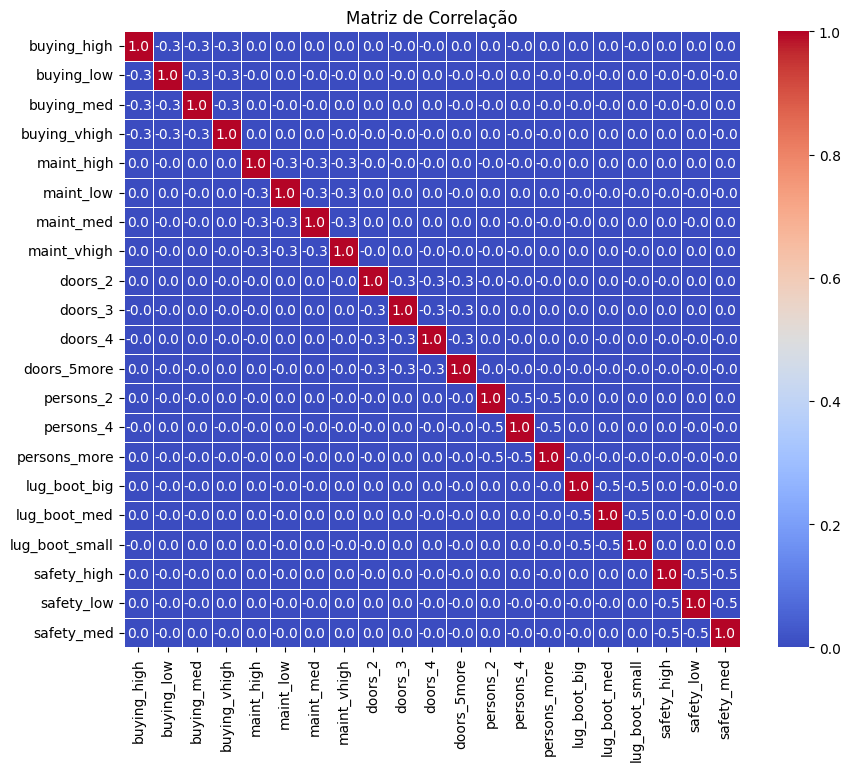

In [109]:
X_corr = carE_numerico_Hot_df.drop(
    ['values_acc', 'values_good', 'values_unacc', 'values_vgood'],
    axis=1
)

corr = X_corr.corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".1f",
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title('Matriz de Correlação')
plt.show()

Atividade 3: agora aplicarei conceitos de estatística para os meus dados, primeiramente realizando a distribuiçãod e frequência de cada coluna que possuo.

In [110]:
carE_dados_df = carE_df.drop('values', axis = 1)
for col in carE_df.columns:
    print(f'\n===== {col} =====')
    
    freq = carE_df[col].value_counts()
    rel = carE_df[col].value_counts(normalize=True)
    
    tabela = pd.DataFrame({
        'Frequência': freq,
        'Frequência (%)': rel * 100
    })
    
    print(tabela)


===== buying =====
        Frequência  Frequência (%)
buying                            
vhigh          432            25.0
high           432            25.0
med            432            25.0
low            432            25.0

===== maint =====
       Frequência  Frequência (%)
maint                            
vhigh         432            25.0
high          432            25.0
med           432            25.0
low           432            25.0

===== doors =====
       Frequência  Frequência (%)
doors                            
2             432            25.0
3             432            25.0
4             432            25.0
5more         432            25.0

===== persons =====
         Frequência  Frequência (%)
persons                            
2               576       33.333333
4               576       33.333333
more            576       33.333333

===== lug_boot =====
          Frequência  Frequência (%)
lug_boot                            
small            576       

Vou fazer um grafico de barras, através dos meus dados percebe-se que as classificações tiveram quantidades diferentes, então os graficos vão ficar com barras de mesmo tamanho ja que são igualmente distribuídos.

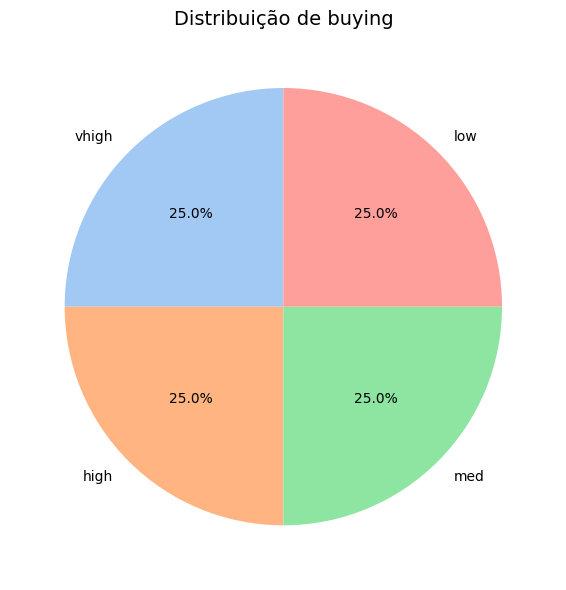

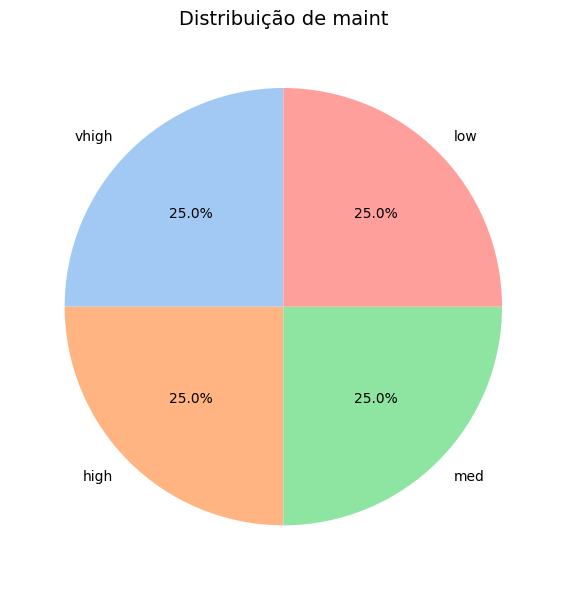

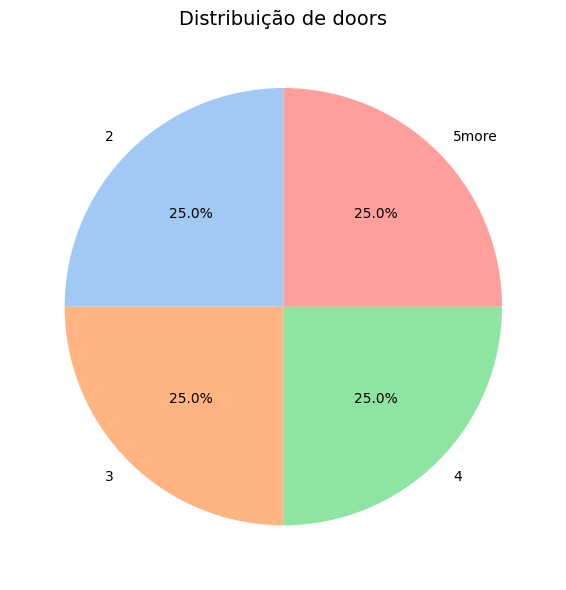

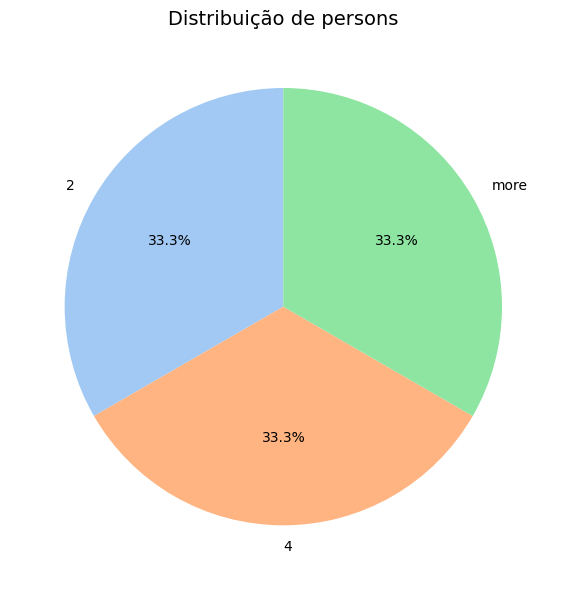

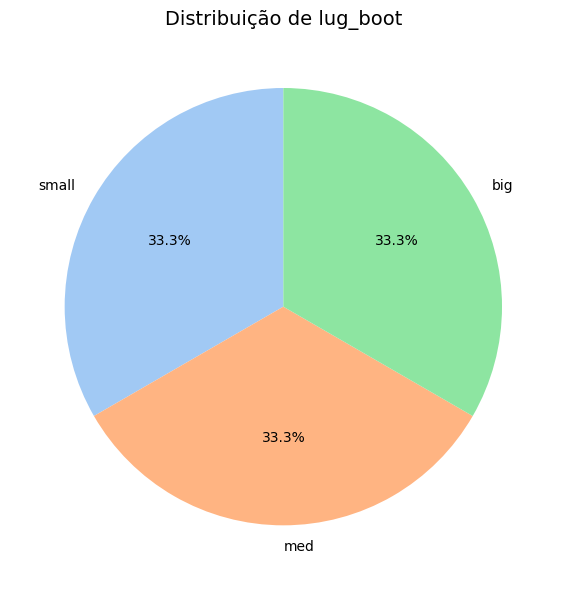

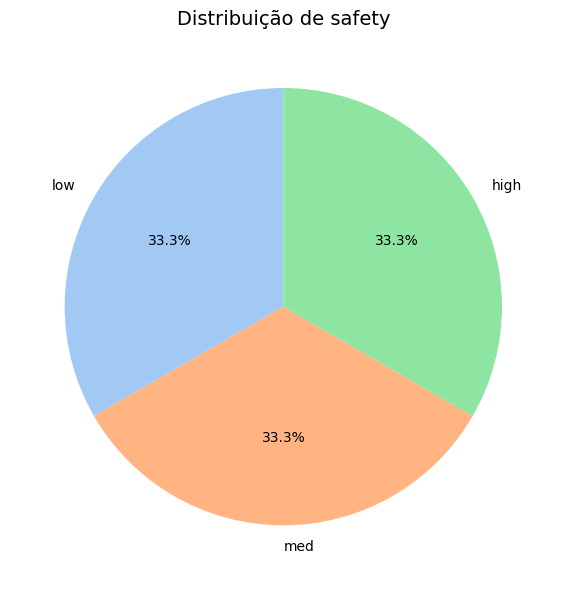

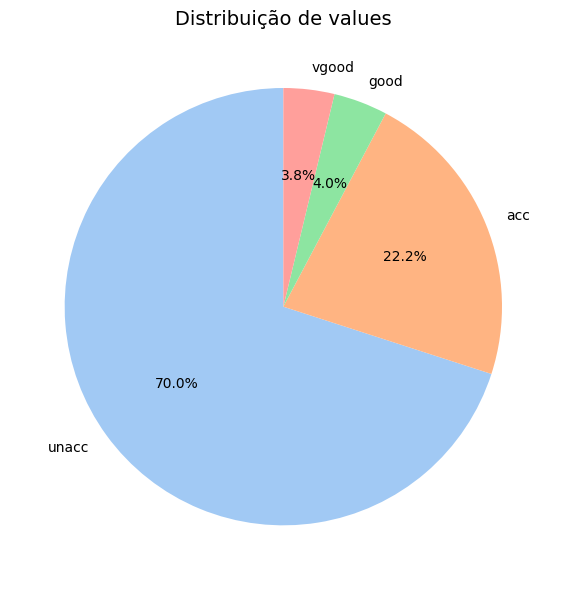

In [111]:

for col in carE_df.columns:
    plt.figure(figsize=(6,6))
    
    freq = carE_df[col].value_counts()
    
    cores = sns.color_palette("pastel", len(freq))
    
    plt.pie(
        freq,
        labels=freq.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=cores,
        shadow=False
    )
    
    plt.title(f'Distribuição de {col}', fontsize=14)
    plt.ylabel('')
    
    plt.tight_layout()
    plt.show()

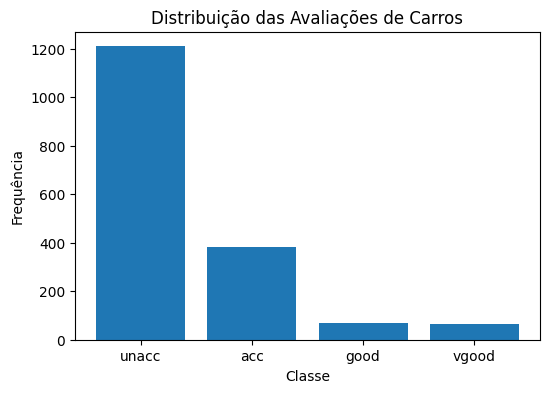

In [112]:
freq = carE_df['values'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    freq.index,
    freq.values
)

plt.title('Distribuição das Avaliações de Carros')
plt.xlabel('Classe')
plt.ylabel('Frequência')

plt.show()

In [113]:
carE_df.head(15)

,buying,maint,doors,persons,lug_boot,safety,values
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


O criador da tabela utilizou todas as classificações possiveis para a contrução oq me fez perceber ser uma tabela montada, por mais que ele tenha pego valores externos com base de colunas que ele já havia estabelecido. Tirei essa conclusão por meio da tabela de frequência

In [23]:
carE_df.describe()

,buying,maint,doors,persons,lug_boot,safety,values
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [114]:
resumo = pd.DataFrame({
    'Média': carE_numerico_Hot_df.mean(),
    'Mediana': carE_numerico_Hot_df.median(),
    'Moda': carE_numerico_Hot_df.mode().iloc[0]
})

print(resumo)

                   Média  Mediana  Moda
buying_high     0.250000      0.0     0
buying_low      0.250000      0.0     0
buying_med      0.250000      0.0     0
buying_vhigh    0.250000      0.0     0
maint_high      0.250000      0.0     0
maint_low       0.250000      0.0     0
maint_med       0.250000      0.0     0
maint_vhigh     0.250000      0.0     0
doors_2         0.250000      0.0     0
doors_3         0.250000      0.0     0
doors_4         0.250000      0.0     0
doors_5more     0.250000      0.0     0
persons_2       0.333333      0.0     0
persons_4       0.333333      0.0     0
persons_more    0.333333      0.0     0
lug_boot_big    0.333333      0.0     0
lug_boot_med    0.333333      0.0     0
lug_boot_small  0.333333      0.0     0
safety_high     0.333333      0.0     0
safety_low      0.333333      0.0     0
safety_med      0.333333      0.0     0
values_acc      0.222222      0.0     0
values_good     0.039931      0.0     0
values_unacc    0.700231      1.0     1


In [117]:
resumo_disp = pd.DataFrame({
    'Variância': carE_numerico_Hot_df.var(),
    'Desvio Padrão': carE_numerico_Hot_df.std(),
    'Amplitude': carE_numerico_Hot_df.max() - carE_numerico_Hot_df.min()
})

print(resumo_disp)

                Variância  Desvio Padrão  Amplitude
buying_high      0.187609       0.433138          1
buying_low       0.187609       0.433138          1
buying_med       0.187609       0.433138          1
buying_vhigh     0.187609       0.433138          1
maint_high       0.187609       0.433138          1
maint_low        0.187609       0.433138          1
maint_med        0.187609       0.433138          1
maint_vhigh      0.187609       0.433138          1
doors_2          0.187609       0.433138          1
doors_3          0.187609       0.433138          1
doors_4          0.187609       0.433138          1
doors_5more      0.187609       0.433138          1
persons_2        0.222351       0.471541          1
persons_4        0.222351       0.471541          1
persons_more     0.222351       0.471541          1
lug_boot_big     0.222351       0.471541          1
lug_boot_med     0.222351       0.471541          1
lug_boot_small   0.222351       0.471541          1
safety_high 

Foram utilizadas medidas de tendência central, dispersão, posição relativa e associação para análise estatística dos dados. Devido à natureza categórica do conjunto, destacam-se principalmente a moda, a distribuição de frequência e as relações entre variáveis.

In [53]:
carE_numerico_Hot_df = carE_numerico_Hot_df.astype(int)
quartis = carE_numerico_Hot_df.quantile([0.25, 0.5, 0.75])

print("\nQuartis:\n", quartis)


Quartis:
       buying_high  buying_low  buying_med  buying_vhigh  maint_high  \
0.25         0.00        0.00        0.00          0.00        0.00   
0.50         0.00        0.00        0.00          0.00        0.00   
0.75         0.25        0.25        0.25          0.25        0.25   

      maint_low  maint_med  maint_vhigh  doors_2  doors_3  ...  lug_boot_big  \
0.25       0.00       0.00         0.00     0.00     0.00  ...           0.0   
0.50       0.00       0.00         0.00     0.00     0.00  ...           0.0   
0.75       0.25       0.25         0.25     0.25     0.25  ...           1.0   

      lug_boot_med  lug_boot_small  safety_high  safety_low  safety_med  \
0.25           0.0             0.0          0.0         0.0         0.0   
0.50           0.0             0.0          0.0         0.0         0.0   
0.75           1.0             1.0          1.0         1.0         1.0   

      values_acc  values_good  values_unacc  values_vgood  
0.25         0.0      

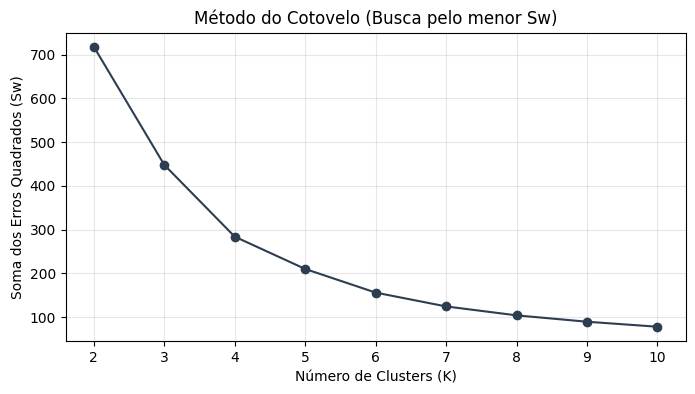

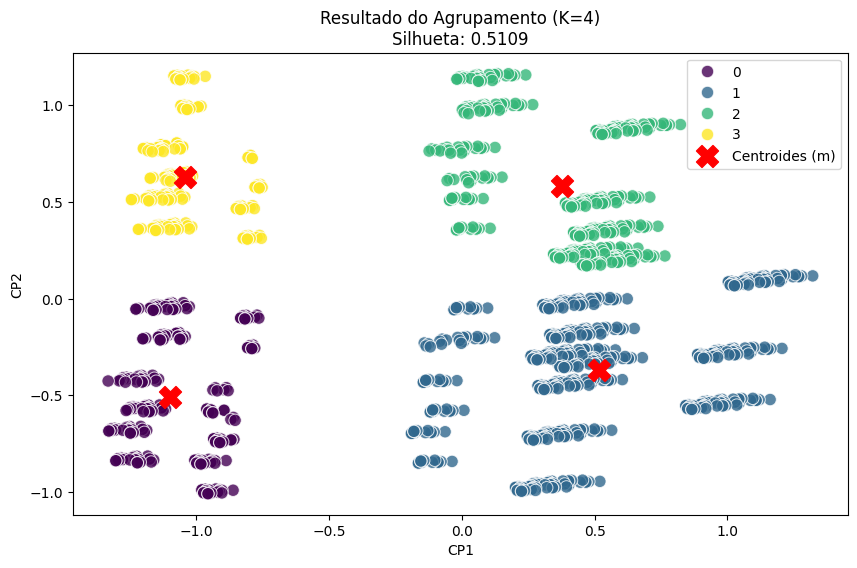

Análise concluída. Sw final: 283.70


In [135]:
carE_analise = carE_numerico_Hot_df

pca_2d = PCA(n_components=2)
dados_pca = pca_2d.fit_transform(carE_analise)
df_pca = pd.DataFrame(data=dados_pca, columns=['CP1', 'CP2'])
sw = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    model.fit(df_pca)
    sw.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, sw, marker='o', color='#2c3e50')
plt.title('Método do Cotovelo (Busca pelo menor Sw)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Soma dos Erros Quadrados (Sw)')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Execução do K-Means com o K escolhido (Exemplo: K=4)
k_final = 4
kmeans_final = KMeans(n_clusters=k_final, init='k-means++', n_init=10, random_state=42)
df_pca['cluster'] = kmeans_final.fit_predict(df_pca)

# 5. Gráfico Final 2D
plt.figure(figsize=(10, 6))

# Pontos dos clusters
sns.scatterplot(
    x='CP1', y='CP2', 
    hue='cluster', 
    data=df_pca, 
    palette='viridis', 
    s=80, 
    alpha=0.8
)

centroids = kmeans_final.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    marker='X', 
    s=250, 
    c='red', 
    label='Centroides (m)'
)

silhueta = silhouette_score(dados_pca, df_pca['cluster'])
plt.title(f'Resultado do Agrupamento (K={k_final})\nSilhueta: {silhueta:.4f}', fontsize=12)
plt.legend()
plt.show()

print(f"Análise concluída. Sw final: {kmeans_final.inertia_:.2f}")